# Grad-CAM Demo on CIFAR-10
This notebook demonstrates how to compute and visualize Grad-CAM for a CNN model.


## 1. Imports

We bring in NumPy/Matplotlib for data handling and visualization plus PyTorch and torchvision for the model and dataset utilities.

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

## 2. Load Model (ResNet18) and CIFAR-10

Define the device (CPU/GPU), fetch CIFAR-10 with normalization, and load a pretrained ResNet-18 so we have a backbone to probe.

In [37]:
# CIFAR-10 normalization
test_transforms = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
])

test_set = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_transforms)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True)

# Pretrained ImageNet ResNet18
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
model.eval()

# Adapt to CIFAR-10
model.fc = nn.Linear(model.fc.in_features, 10)

## 3. Exercise: Train Your Own CIFAR-10 ConvNet

Exercise prompt: replace the pretrained weights with a model you trained on CIFAR-10. Suggested steps:
- Define a small ConvNet (e.g., SimpleCNN or a tiny ResNet).
- Create CIFAR-10 loaders with augmentations and normalization.
- Train for several epochs with cross-entropy + SGD/Adam, then evaluate on the test set.
- Save the checkpoint (e.g., `cifar_custom.pth`).
- Update the path below and load your weights so Grad-CAM runs on your model.

In [38]:
# TODO: After training your own CIFAR-10 model, set the checkpoint path and load it here.
# checkpoint_path = 'cifar_custom.pth'
# model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
# model.eval()

# Train your own CIFAR-10 ConvNet (ResNet18) and load it

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fresh model (same architecture as above, compatible with Grad-CAM hooks)
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 10)
model.to(device)

# Data
train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
train_set = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_transforms)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

# Optimizer / loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# Train (quick run; increase epochs for better accuracy)
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader.dataset):.4f}")

# Save and load checkpoint
checkpoint_path = "cifar_custom.pth"
torch.save(model.state_dict(), checkpoint_path)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()  # keep eval mode for Grad-CAM


/home/ebezerra/anaconda3/envs/ml4ds/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/5 - Loss: 0.8922
Epoch 2/5 - Loss: 0.5689
Epoch 3/5 - Loss: 0.4648
Epoch 4/5 - Loss: 0.3978
Epoch 5/5 - Loss: 0.3455


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4. Grad-CAM Hook Helpers

Register forward/backward hooks on the target layer to capture feature maps and gradients that will drive the Grad-CAM heatmap.

In [39]:
feature_maps = None
gradients = None

def forward_hook(module, input, output):
    global feature_maps
    feature_maps = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4[1].conv2
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

## 5. Compute Grad-CAM

Run a forward/backward pass for a chosen class, weight feature maps by the pooled gradients, and normalize the resulting heatmap.

In [40]:
def compute_gradcam(input_tensor, class_idx=None):
    global feature_maps, gradients

    output = model(input_tensor)

    if class_idx is None:
        class_idx = output.argmax().item()

    model.zero_grad()
    target = output[0, class_idx]
    target.backward()

    weights = gradients.mean(dim=[1, 2])

    # Build 2D CAM (H, W) to avoid broadcasting extra dimensions
    cam = torch.zeros(feature_maps.shape[2:], dtype=torch.float32, device=feature_maps.device)
    for i, w in enumerate(weights):
        cam += w * feature_maps[0, i, :, :]

    cam = torch.relu(cam)
    cam -= cam.min()
    cam /= cam.max()

    return cam.detach().cpu().numpy(), class_idx


## 6. Visualization

Define how to plot the original image alongside the Grad-CAM heatmap. We unnormalize the tensor back to RGB values, resize the CAM to the image size, and overlay it with a transparent jet colormap so you can see which regions the model focuses on.

In [41]:
def show_gradcam(image_tensor, cam, class_name):
    # image_tensor: (1, C, H, W) or (C, H, W)
    img = image_tensor.squeeze().detach().cpu().numpy().transpose(1,2,0)
    img = img * np.array([0.2470,0.2435,0.2616]) + np.array([0.4914,0.4822,0.4465])
    img = np.clip(img, 0, 1)  # keep within displayable range

    # Resize CAM to image size using bilinear interpolation (avoids np.interp 1D limitation)
    cam_tensor = torch.tensor(cam, dtype=torch.float32)[None, None, ...]
    cam_resized = torch.nn.functional.interpolate(cam_tensor, size=img.shape[:2], mode="bilinear", align_corners=False)
    cam_resized = cam_resized.squeeze().cpu().numpy()

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title(f"Grad-CAM ({class_name})")
    plt.imshow(img, alpha=0.6)
    plt.imshow(cam_resized, cmap='jet', alpha=0.4)
    plt.axis("off")

    plt.show()


## 7. Run Grad-CAM

Pick a sample from the CIFAR-10 test loader, run the model to get its predicted class, compute Grad-CAM for that class, and visualize the result. This section ties everything together so you can interpret the model's decision for a real image.

True label: airplane
Predicted label: airplane


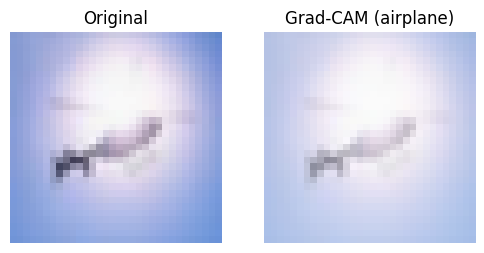

In [42]:
classes = test_set.classes

image, label = next(iter(test_loader))
print("True label:", classes[label[0]])

cam, class_idx = compute_gradcam(image)
print("Predicted label:", classes[class_idx])

show_gradcam(image, cam, classes[class_idx])